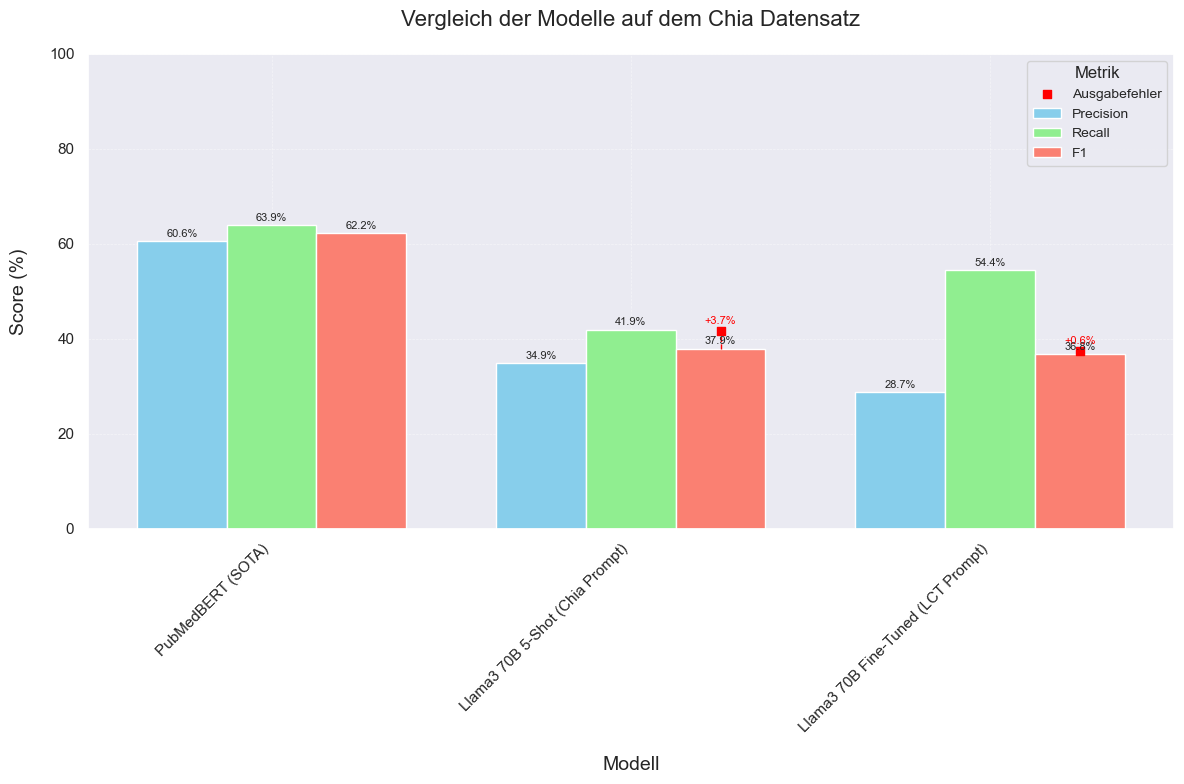

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Daten vorbereiten
data = {
    'Model': ['PubMedBERT (SOTA)', 'Llama3 70B 5-Shot (Chia Prompt)', 'Llama3 70B Fine-Tuned (LCT Prompt)'],
    'P': [60.6, 34.9, 28.7],
    'R': [63.9, 41.9, 54.4],
    'F1': [62.2, 37.9, 36.8],
    'Ausgabefehler': [np.nan, 3.7, 0.6],
    'Type': ['SOTA', 'LLM', 'LLM']
}

df = pd.DataFrame(data)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))

# Balken für P, R, und F1
x = np.arange(len(df))
width = 0.25

ax.bar(x - width, df['P'], width, label='Precision', color='skyblue')
ax.bar(x, df['R'], width, label='Recall', color='lightgreen')
ax.bar(x + width, df['F1'], width, label='F1', color='salmon')

# Ausgabefehler als rote Quadrate und gestrichelte Linien hinzufügen
for i, (model, f1, ausgabefehler) in enumerate(zip(df['Model'], df['F1'], df['Ausgabefehler'])):
    if not np.isnan(ausgabefehler):
        total_height = f1 + ausgabefehler
        ax.plot([i + width, i + width], [f1, total_height], color='red', linestyle='--', linewidth=1)
        ax.scatter(i + width, total_height, color='red', marker='s', s=30, zorder=3)
        ax.text(i + width, total_height + 1, f'+{ausgabefehler:.1f}%', ha='center', va='bottom', fontsize=8, color='red')

# Titel und Labels
plt.title('Vergleich der Modelle auf dem Chia Datensatz', fontsize=16, pad=20)
ax.set_xlabel('Modell', fontsize=14, labelpad=15)
ax.set_ylabel('Score (%)', fontsize=14, labelpad=15)

# X-Achsen-Labels
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=45, ha='right')

# Y-Achse anpassen
ax.set_ylim(0, 100)

# Legende
ax.legend(title='Metrik', title_fontsize=12, fontsize=10)

# Gitterlinien
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Wertbeschriftungen hinzufügen
for i, metrics in enumerate(zip(df['P'], df['R'], df['F1'])):
    for j, v in enumerate(metrics):
        ax.text(i + (j-1)*width, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

# Legende für Ausgabefehler hinzufügen
ax.scatter([], [], color='red', marker='s', label='Ausgabefehler', s=30)
ax.legend(title='Metrik', title_fontsize=12, fontsize=10)

plt.tight_layout()

# Als PNG speichern
plt.savefig('chia_vergleich.png', format='png', bbox_inches='tight')

plt.show()

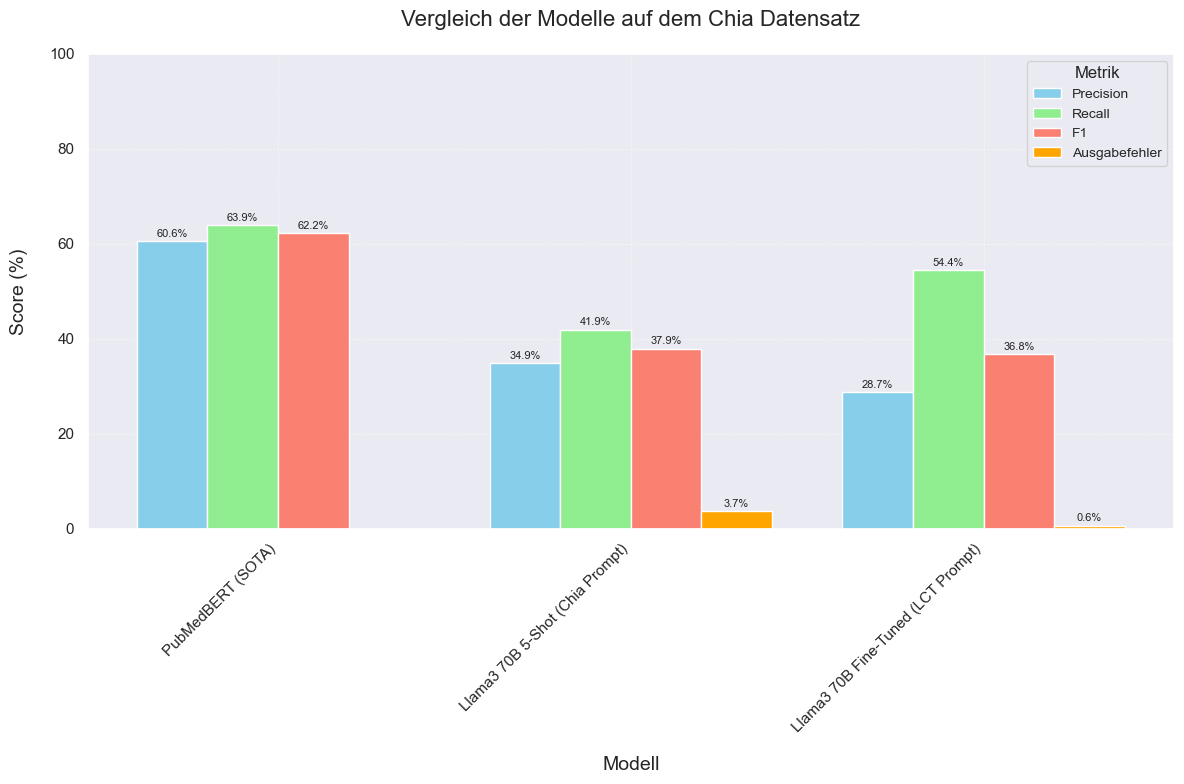

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Daten vorbereiten
data = {
    'Model': ['PubMedBERT (SOTA)', 'Llama3 70B 5-Shot (Chia Prompt)', 'Llama3 70B Fine-Tuned (LCT Prompt)'],
    'P': [60.6, 34.9, 28.7],
    'R': [63.9, 41.9, 54.4],
    'F1': [62.2, 37.9, 36.8],
    'Ausgabefehler': [np.nan, 3.7, 0.6],
    'Type': ['SOTA', 'LLM', 'LLM']
}

df = pd.DataFrame(data)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
sns.set_theme(style="darkgrid")
# Balken für P, R, F1 und Ausgabefehler
x = np.arange(len(df))
width = 0.2

ax.bar(x - 1.5*width, df['P'], width, label='Precision', color='skyblue')
ax.bar(x - 0.5*width, df['R'], width, label='Recall', color='lightgreen')
ax.bar(x + 0.5*width, df['F1'], width, label='F1', color='salmon')
ax.bar(x + 1.5*width, df['Ausgabefehler'], width, label='Ausgabefehler', color='orange')

# Titel und Labels
plt.title('Vergleich der Modelle auf dem Chia Datensatz', fontsize=16, pad=20)
ax.set_xlabel('Modell', fontsize=14, labelpad=15)
ax.set_ylabel('Score (%)', fontsize=14, labelpad=15)

# X-Achsen-Labels
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=45, ha='right')

# Y-Achse anpassen
ax.set_ylim(0, 100)

# Legende
ax.legend(title='Metrik', title_fontsize=12, fontsize=10)

# Gitterlinien
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Wertbeschriftungen hinzufügen
metrics_list = ['P', 'R', 'F1', 'Ausgabefehler']
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']
for i in range(len(df)):
    for j, metric in enumerate(metrics_list):
        value = df.iloc[i][metric]
        if not np.isnan(value):
            ax.text(i + (j - 1.5)*width, value + 0.5, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()

# Als PNG speichern
plt.savefig('chia_vergleich.png', format='png', bbox_inches='tight')

plt.show()
